/mbz/users/liyuan/miniconda3/envs/myenv/lib/python3.10/site-packages/scipy/optimize/_differentiable_functions.py:551: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)
/mbz/users/liyuan/miniconda3/envs/myenv/lib/python3.10/site-packages/scipy/optimize/_differentiable_functions.py:316: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


=== [Domain 1] Step2 success: Fitted c,gamma,alpha,e with Beta=0.0663 ===
   c     = 0.298204
   gamma = 0.000111
   alpha = 0.140976
   e     = 1.690515
   Huber objective = 0.000012
   gamma*(2/3*N)^alpha / (2/3*N) = 0.000062


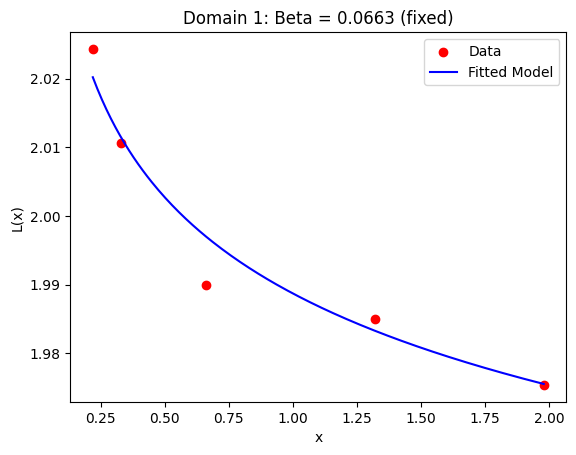

=== [Domain 2] Step2 success: Fitted c,gamma,alpha,e with Beta=0.0391 ===
   c     = 1.160433
   gamma = 0.196290
   alpha = 0.527331
   e     = 0.829842
   Huber objective = 0.000009
   gamma*(2/3*N)^alpha / (2/3*N) = 0.142126


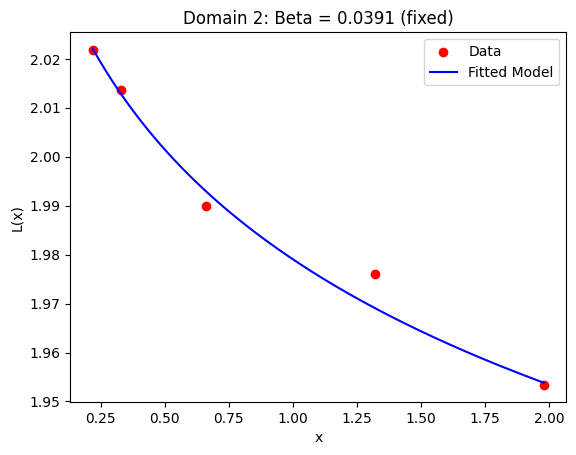

=== [Domain 3] Step2 success: Fitted c,gamma,alpha,e with Beta=0.0583 ===
   c     = 1.019107
   gamma = 1.149657
   alpha = 0.590161
   e     = 1.023279
   Huber objective = 0.000015
   gamma*(2/3*N)^alpha / (2/3*N) = 0.868927


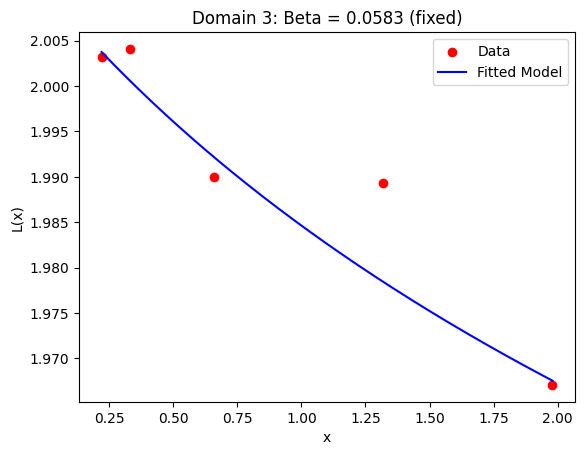

=== [Domain 4] Step2 success: Fitted c,gamma,alpha,e with Beta=0.0907 ===
   c     = 0.169170
   gamma = 0.000059
   alpha = 0.398889
   e     = 1.818890
   Huber objective = 0.000021
   gamma*(2/3*N)^alpha / (2/3*N) = 0.000039


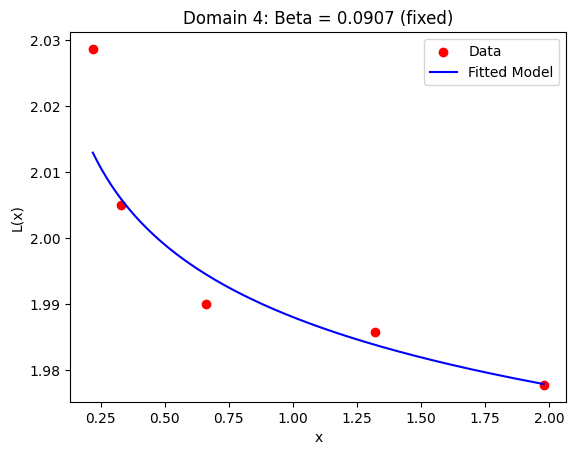


--- All domains completed ---
{'beta': 0.0663, 'c': 0.29820374984208625, 'gamma': 0.00011068560596411354, 'alpha': 0.14097555628814534, 'e': 1.6905148547285012}
{'beta': 0.0391, 'c': 1.1604332508577435, 'gamma': 0.19628996676565671, 'alpha': 0.5273313339880505, 'e': 0.8298415306908238}
{'beta': 0.0583, 'c': 1.0191071790756916, 'gamma': 1.149656533855345, 'alpha': 0.5901611824007924, 'e': 1.0232791258415534}
{'beta': 0.0907, 'c': 0.1691704656232784, 'gamma': 5.8546895176083784e-05, 'alpha': 0.3988889526546355, 'e': 1.818889652568379}


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, NonlinearConstraint, Bounds, BFGS

# ===============================================================
# 1. Data Setup
# ===============================================================
base_token = 0.66
N = 4 * base_token  # 'N' from your original context
x_vals = np.array([i * base_token for i in [1/3, 1/2, 1, 2, 3]])

# Each row in 'lyst' corresponds to a domain's L-values, i.e. 5 data points.
# We'll treat each row separately (each domain has its own parameters).
lyst = [
   [2.024321116482459, 2.0105952584479216, 1.990, 1.9849282346653605, 1.9753737257904833],
    [2.0217433752861744, 2.0135445270790187, 1.990, 1.9759611105003072, 1.9533850007715063],
    [2.003216376124854, 2.004087887878923, 1.990, 1.9893702644617437, 1.9670705488252318],
    [2.0286690995573027, 2.0050834446692827, 1.990, 1.9858337752939834, 1.97776485902538]
]

# ===============================================================
# 2. Define the Model
# ===============================================================
def model(N_i, c, gamma, alpha, beta, e):
    """
    model(N_i, c, gamma, alpha, beta, e) 
      = c * (N_i + gamma*(2/3*N)^alpha)^(-beta) + e
    """
    inner_term = (3.0/4.0)*N
    return c * (N_i + gamma * (inner_term ** alpha)) ** (-beta) + e


# # ===============================================================
# # 4. Step 2: With beta fixed, optimize {c, gamma, alpha, e}
# # ===============================================================
# #
# # We'll reuse your Huber-loss approach and the same constraint:
# #    gamma*(2/3*N)^alpha < (2/3*N).
# #
def huber_loss(residuals, delta=0.001):
    abs_r = np.abs(residuals)
    mask_quadratic = abs_r <= delta
    return np.where(
        mask_quadratic,
        0.5 * residuals**2,
        delta * (abs_r - 0.5 * delta),
    )

def objective_fixed_beta(params, x, y, beta_fixed):
    """
    params = [log_c, log_gamma, alpha, log_e]
      => c = exp(log_c), gamma = exp(log_gamma), e = exp(log_e)
    """
    log_c, log_gamma, alpha, log_e = params
    c_ = np.exp(log_c)
    gamma_ = np.exp(log_gamma)
    e_ = np.exp(log_e)
    
    y_pred = model(x, c_, gamma_, alpha, beta_fixed, e_)
    residuals = y - y_pred
    return np.sum(huber_loss(residuals, delta=0.001))

def constraint_fun_fixed_beta(p, beta_fixed):
    """
    p = [log_c, log_gamma, alpha, log_e]
    We want: gamma*(2/3*N)^alpha < (2/3*N).
    => gamma*(inner_term^alpha) - inner_term <= 0
    """
    _, log_gamma, alpha, _ = p
    gamma_ = np.exp(log_gamma)
    inner_term = (3.0/4.0)*N
    return gamma_ * (inner_term ** alpha) - inner_term

# Bounds for [log_c, log_gamma, alpha, log_e].
# alpha >= 0, alpha <= 1 (if you want that constraint).
bounds_fixed_beta = Bounds(
    lb=[-np.inf, -np.inf, 0.0, -np.inf],  
    ub=[ np.inf,  np.inf, 1,  np.inf]  
)
# [log_c, log_gamma, alpha, log_e]

# ===============================================================
# 5. Putting it all together
# ===============================================================
optimized_parameters = []

beta = [0.0663, 0.0391, 0.0583, 0.0907]
for domain_index, Lvals_raw in enumerate(lyst, start=1):
    # Convert to numpy array
    Lvals = np.array(Lvals_raw)
    
    # ------------------------------------------------
    # Step 1: Estimate beta (and A) from ratio approach
    # ------------------------------------------------
    beta_est = beta[domain_index-1]
    
    # --------------------------------------------
    # Step 2: Fix beta => fit c, gamma, alpha, e
    # --------------------------------------------
    def objective_to_minimize(p, x, y):
        return objective_fixed_beta(p, x, y, beta_est)
    
    def constraint_fun(p):
        return constraint_fun_fixed_beta(p, beta_est)
    
    nonlinear_constraint_fixed = NonlinearConstraint(
        fun=constraint_fun,
        lb=-np.inf,
        ub=0.0,
        jac='2-point',
        hess=BFGS()
    )
    
    # Initial guess for [log_c, log_gamma, alpha, log_e].
    # e.g. c=2.0 => log_c=ln(2), gamma=0.5 => log_gamma=ln(0.5), alpha=0.5, e=1.0 => log_e=ln(1)
    initial_guess_fixed = [np.log(3.0), np.log(0.5), 0.5, np.log(1.0)]
    
    res = minimize(
        fun=objective_to_minimize,
        x0=initial_guess_fixed,
        args=(x_vals, Lvals),
        method='trust-constr',
        jac='2-point',
        hess=BFGS(),
        bounds=bounds_fixed_beta,
        constraints=[nonlinear_constraint_fixed],
        options={'maxiter': 10000, 'verbose': 0},
    )
    
    if res.success:
        log_c_opt, log_gamma_opt, alpha_opt, log_e_opt = res.x
        c_opt = np.exp(log_c_opt)
        gamma_opt = np.exp(log_gamma_opt)
        e_opt = np.exp(log_e_opt)
        
        results_dict = {
            'beta': beta_est,
            'c': c_opt,
            'gamma': gamma_opt,
            'alpha': alpha_opt,
            'e': e_opt
        }
        optimized_parameters.append(results_dict)
        
        print(f"=== [Domain {domain_index}] Step2 success: Fitted c,gamma,alpha,e with Beta={beta_est:.4f} ===")
        print(f"   c     = {c_opt:.6f}")
        print(f"   gamma = {gamma_opt:.6f}")
        print(f"   alpha = {alpha_opt:.6f}")
        print(f"   e     = {e_opt:.6f}")
        print(f"   Huber objective = {res.fun:.6f}")
        
        # Check constraint ratio
        ratio = (gamma_opt * ((3.0/4.0)*N)**alpha_opt) / ((3.0/4.0)*N)
        print(f"   gamma*(2/3*N)^alpha / (2/3*N) = {ratio:.6f}")
        
        # Plot the data + fitted curve
        x_fine = np.linspace(x_vals.min(), x_vals.max(), 200)
        y_fitted = model(x_fine, c_opt, gamma_opt, alpha_opt, beta_est, e_opt)
        
        plt.figure()
        plt.scatter(x_vals, Lvals, color='red', label='Data')
        plt.plot(x_fine, y_fitted, color='blue', label='Fitted Model')
        plt.title(f'Domain {domain_index}: Beta = {beta_est:.4f} (fixed)')
        plt.xlabel('x')
        plt.ylabel('L(x)')
        plt.legend()
        plt.show()
    else:
        print(f"=== [Domain {domain_index}] Step2 optimization failed ===")
        print("Message:", res.message)

# ===============================================================
# 6. Summaries
# ===============================================================
print("\n--- All domains completed ---")
for param_dict in optimized_parameters:
    print(param_dict)


In [12]:
for param_dict in optimized_parameters:
    print(param_dict)

{'beta': 0.051, 'c': 1.1563830710524174, 'gamma': 0.19805402304500302, 'alpha': 0.4703440635345293, 'e': 1.0965417101247577}
{'beta': 0.043, 'c': 0.7534755393034062, 'gamma': 0.04213572818124636, 'alpha': 0.40402334237756804, 'e': 1.4912139228085828}
{'beta': 0.0439, 'c': 0.9839313256887255, 'gamma': 0.12753654870791545, 'alpha': 0.44650550960027646, 'e': 1.2659943856844356}


=== [Domain 1] success: c,gamma,alpha,e with Beta=0.0510 ===
   c     = 1.157170
   gamma = 0.199446
   alpha = 0.454331
   e     = 1.095797
   Huber objective = 0.000005
   gamma*(2/3*N)^alpha / (2/3*N) = 0.171408


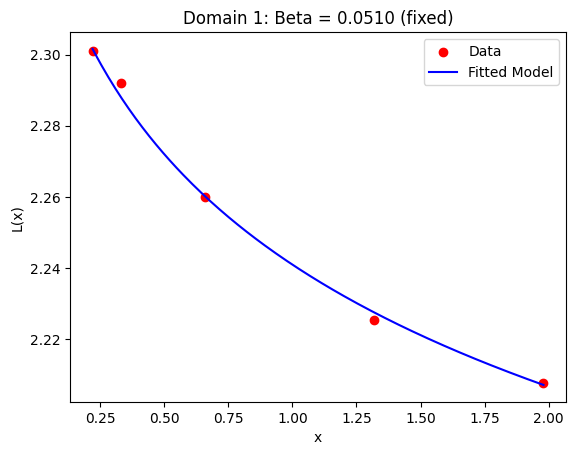

=== [Domain 2] success: c,gamma,alpha,e with Beta=0.0430 ===
   c     = 0.779436
   gamma = 0.059448
   alpha = 0.418994
   e     = 1.466222
   Huber objective = 0.000005
   gamma*(2/3*N)^alpha / (2/3*N) = 0.050592


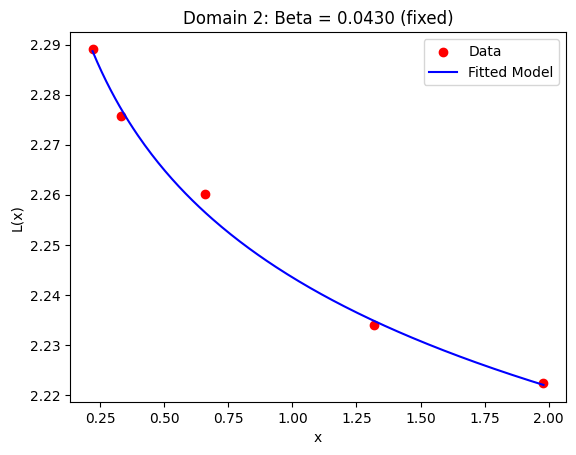

=== [Domain 3] success: c,gamma,alpha,e with Beta=0.0439 ===
   c     = 0.984918
   gamma = 0.127997
   alpha = 0.451849
   e     = 1.265047
   Huber objective = 0.000001
   gamma*(2/3*N)^alpha / (2/3*N) = 0.109928


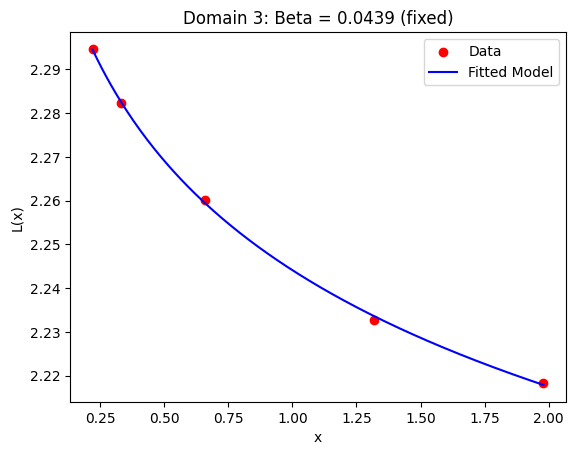


--- All domains completed ---
{'beta': 0.051, 'c': 1.1571703908358502, 'gamma': 0.19944597703250588, 'alpha': 0.4543311730281822, 'e': 1.0957965206742064}
{'beta': 0.043, 'c': 0.7794363696165698, 'gamma': 0.05944777621500164, 'alpha': 0.4189942123018014, 'e': 1.4662217225889453}
{'beta': 0.0439, 'c': 0.9849184550881703, 'gamma': 0.1279968581239326, 'alpha': 0.45184902420795714, 'e': 1.265046799160259}


In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, NonlinearConstraint, Bounds, BFGS

# ===============================================================
# 1. Data Setup
# ===============================================================
base_token = 0.66
N = 3 * base_token  # 'N' from your original context
x_vals = np.array([i * base_token for i in [1/3, 1/2, 1, 2, 3]])

# Each row in 'lyst' corresponds to a domain's L-values, i.e. 5 data points.
lyst = [
    [2.3009398127536653, 2.2919550197611414, 2.2601072040502985, 2.2253171055400482, 2.2078428253445472],
    [2.2891207768582373, 2.275715067349909,  2.2601072040502985, 2.2340252519100123, 2.2223123883020706],
    [2.2946755321189904, 2.2822197449260098, 2.2601072040502985, 2.2327336034851544, 2.2183251314478096]
]

# Suppose you have beta estimates from a prior approach:
beta_values = [0.0510, 0.0430, 0.0439]

# ===============================================================
# 2. Define the Model
#    c and e are in log-scale: c = exp(c_log), e = exp(e_log)
#    gamma is used directly, alpha is used directly, beta is fixed.
# ===============================================================
def model(N_i, c_log, gamma, alpha, beta, e_log):
    """
    model(N_i) = exp(c_log) * (N_i + gamma*(2/3*N)^alpha)^(-beta) + exp(e_log)
    """
    c = np.exp(c_log)
    e = np.exp(e_log)
    inner_term = (2.0/3.0) * N
    return c * (N_i + gamma * (inner_term ** alpha)) ** (-beta) + e

# ===============================================================
# 3. Huber Loss
# ===============================================================
def huber_loss(residuals, delta=0.001):
    """
    Huber loss for robust regression:
      - Quadratic for small residuals (|r| <= delta).
      - Linear for large residuals (|r| > delta).
    """
    abs_r = np.abs(residuals)
    mask_quadratic = abs_r <= delta
    
    # Quadratic region
    quad_part = 0.5 * residuals**2
    # Linear region
    linear_part = delta * (abs_r - 0.5 * delta)
    
    return np.where(mask_quadratic, quad_part, linear_part)

# ===============================================================
# 4. Objective for c_log, gamma, alpha, e_log with beta fixed
# ===============================================================
def objective_fixed_beta(params, x, y, beta_fixed):
    """
    params = [c_log, gamma, alpha, e_log]
      c_log : real (no bound in principle)
      gamma : direct, >= 0
      alpha : in [0,1]
      e_log : real (no bound in principle)
    """
    c_log = params[0]
    gamma_ = params[1]
    alpha_ = params[2]
    e_log = params[3]
    
    # Compute predictions
    y_pred = model(x, c_log, gamma_, alpha_, beta_fixed, e_log)
    # Residuals
    residuals = y - y_pred
    # Return sum of Huber losses
    return np.sum(huber_loss(residuals, delta=0.001))

# ===============================================================
# 5. Constraint: gamma*(2/3*N)^alpha < (2/3*N)
#    (no log parameter for gamma, so we use gamma directly)
# ===============================================================
def constraint_fun_fixed_beta(params, beta_fixed):
    """
    We want: gamma*(2/3*N)^alpha - (2/3*N) <= 0
    """
    # c_log = params[0]  # not needed for constraint
    gamma_ = params[1]
    alpha_ = params[2]
    # e_log = params[3]  # not needed for constraint
    
    inner_term = (2.0/3.0) * N
    return gamma_ * (inner_term ** alpha_) - inner_term

# ===============================================================
# 6. Parameter Bounds
#    c_log: (-inf, inf)
#    gamma: [0, inf)
#    alpha: [0, 1]
#    e_log: (-inf, inf)
# ===============================================================
lb = [-np.inf, 0.0, 0.0, -np.inf]   # c_log, gamma >=0, alpha>=0, e_log
ub = [ np.inf, np.inf, 1.0,  np.inf]
bounds_fixed_beta = Bounds(lb, ub)

# ===============================================================
# 7. Putting it all together
# ===============================================================
optimized_parameters = []

for domain_index, Lvals_raw in enumerate(lyst, start=1):
    Lvals = np.array(Lvals_raw)
    beta_est = beta_values[domain_index - 1]
    
    # Define the objective and constraint for current domain & fixed beta
    def objective_to_minimize(p, x, y):
        return objective_fixed_beta(p, x, y, beta_est)
    
    def constraint_fun(p):
        return constraint_fun_fixed_beta(p, beta_est)
    
    nonlinear_constraint_fixed = NonlinearConstraint(
        fun=constraint_fun,
        lb=-np.inf,
        ub=0.0,     # gamma*(2/3*N)^alpha <= (2/3*N)
        jac='2-point',
        hess=BFGS()
    )
    
    initial_guess = [
        0.0,    # c_log = log(1.0)
        0.5,    # gamma
        1,    # alpha
        2.0     # e_log = log(1.0)
    ]
    
    # Optimize
    res = minimize(
        fun=objective_to_minimize,
        x0=initial_guess,
        args=(x_vals, Lvals),
        method='trust-constr',
        jac='2-point',
        hess=BFGS(),
        bounds=bounds_fixed_beta,
        constraints=[nonlinear_constraint_fixed],
        options={'maxiter': 3000, 'verbose': 0},
    )
    
    if res.success:
        # Unpack the parameters
        c_log_opt, gamma_opt, alpha_opt, e_log_opt = res.x
        
        # Convert back to original scale for c, e
        c_opt = np.exp(c_log_opt)
        e_opt = np.exp(e_log_opt)
        
        results_dict = {
            'beta': beta_est,
            'c': c_opt,
            'gamma': gamma_opt,
            'alpha': alpha_opt,
            'e': e_opt
        }
        optimized_parameters.append(results_dict)
        
        print(f"=== [Domain {domain_index}] success: c,gamma,alpha,e with Beta={beta_est:.4f} ===")
        print(f"   c     = {c_opt:.6f}")
        print(f"   gamma = {gamma_opt:.6f}")
        print(f"   alpha = {alpha_opt:.6f}")
        print(f"   e     = {e_opt:.6f}")
        print(f"   Huber objective = {res.fun:.6f}")
        
        # Check constraint ratio
        inner_term = (2.0/3.0) * N
        ratio = gamma_opt * (inner_term ** alpha_opt) / inner_term
        print(f"   gamma*(2/3*N)^alpha / (2/3*N) = {ratio:.6f}")
        
        # --- Optional: Plot the data + fitted curve
        x_fine = np.linspace(x_vals.min(), x_vals.max(), 200)
        y_fitted = model(x_fine, c_log_opt, gamma_opt, alpha_opt, beta_est, e_log_opt)
        
        plt.figure()
        plt.scatter(x_vals, Lvals, color='red', label='Data')
        plt.plot(x_fine, y_fitted, color='blue', label='Fitted Model')
        plt.title(f'Domain {domain_index}: Beta = {beta_est:.4f} (fixed)')
        plt.xlabel('x')
        plt.ylabel('L(x)')
        plt.legend()
        plt.show()
    else:
        print(f"=== [Domain {domain_index}] Optimization failed ===")
        print("Message:", res.message)

# ===============================================================
# 8. Print Summaries
# ===============================================================
print("\n--- All domains completed ---")
for param_dict in optimized_parameters:
    print(param_dict)


In [ ]:
{'beta': 0.051, 'c': 1.1571703908358502, 'gamma': 0.19944597703250588, 'alpha': 0.4543311730281822, 'e': 1.0957965206742064}
{'beta': 0.043, 'c': 0.7794363696165698, 'gamma': 0.05944777621500164, 'alpha': 0.4189942123018014, 'e': 1.4662217225889453}
{'beta': 0.0439, 'c': 0.9849184550881703, 'gamma': 0.1279968581239326, 'alpha': 0.45184902420795714, 'e': 1.265046799160259}

{'beta': 0.051, 'c': 1.1571703908358502, 'gamma': 0.19944597703250588, 'alpha': 0.4543311730281822, 'e': 1.0957965206742064}
{'beta': 0.043, 'c': 0.7794363696165698, 'gamma': 0.05944777621500164, 'alpha': 0.4189942123018014, 'e': 1.4662217225889453}
{'beta': 0.0439, 'c': 0.6798944628460741, 'gamma': 0.002216282228350977, 'alpha': 0.4691430912917157, 'e': 1.5682947343352533}

/mbz/users/liyuan/miniconda3/envs/myenv/lib/python3.10/site-packages/scipy/optimize/_differentiable_functions.py:551: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)
/mbz/users/liyuan/miniconda3/envs/myenv/lib/python3.10/site-packages/scipy/optimize/_differentiable_functions.py:316: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


=== [Domain 1] success: c,gamma,alpha,e with Beta=0.0510 ===
   c     = 1.156213
   gamma = 0.194752
   alpha = 0.528822
   e     = 1.096703
   Huber objective = 0.000005
   gamma*(2/3*N)^alpha / (2/3*N) = 0.170872


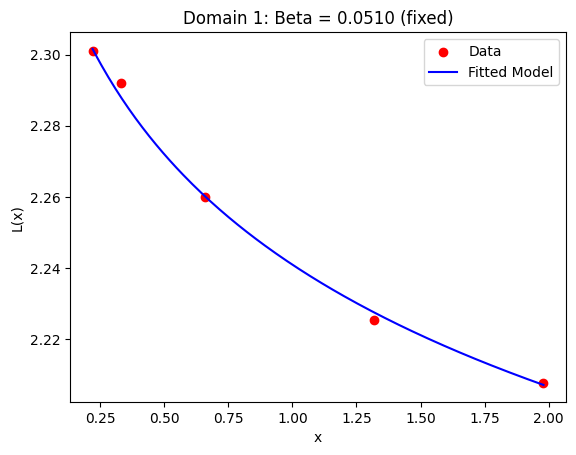

=== [Domain 2] success: c,gamma,alpha,e with Beta=0.0430 ===
   c     = 0.751154
   gamma = 0.040095
   alpha = 0.446723
   e     = 1.493450
   Huber objective = 0.000005
   gamma*(2/3*N)^alpha / (2/3*N) = 0.034386


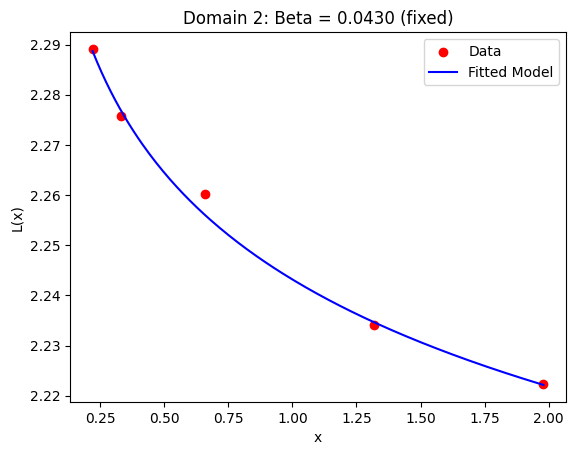

=== [Domain 3] success: c,gamma,alpha,e with Beta=0.0439 ===
   c     = 0.981949
   gamma = 0.123538
   alpha = 0.523541
   e     = 1.267896
   Huber objective = 0.000001
   gamma*(2/3*N)^alpha / (2/3*N) = 0.108231


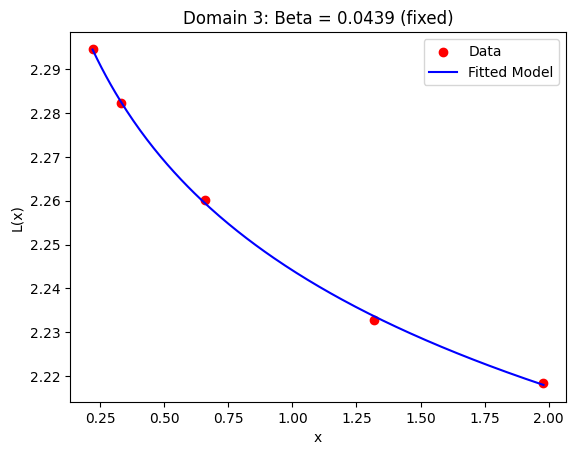


--- All domains completed ---
{'beta': 0.051, 'c': 1.1562126452050558, 'gamma': 0.1947519521525228, 'alpha': 0.5288218202765095, 'e': 1.0967026063933014}
{'beta': 0.043, 'c': 0.7511537761169697, 'gamma': 0.04009487286430519, 'alpha': 0.4467225600130341, 'e': 1.4934499480576826}
{'beta': 0.0439, 'c': 0.9819486347623388, 'gamma': 0.12353804818048429, 'alpha': 0.5235413916210214, 'e': 1.2678961381127019}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, NonlinearConstraint, Bounds, BFGS

# ===============================================================
# 1. Data Setup
# ===============================================================
base_token = 0.66
N = 3 * base_token  # 'N' from your original context
x_vals = np.array([i * base_token for i in [1/3, 1/2, 1, 2, 3]])

# Each row in 'lyst' corresponds to a domain's L-values, i.e. 5 data points.
lyst = [
    [2.3009398127536653, 2.2919550197611414, 2.2601072040502985, 2.2253171055400482, 2.2078428253445472],
    [2.2891207768582373, 2.275715067349909,  2.2601072040502985, 2.2340252519100123, 2.2223123883020706],
    [2.2946755321189904, 2.2822197449260098, 2.2601072040502985, 2.2327336034851544, 2.2183251314478096]
]

# Suppose you have beta estimates from a prior approach:
beta_values = [0.0510, 0.0430, 0.0439]

# ===============================================================
# 2. Define the Model
#    c = exp(c_log), gamma = exp(gamma_log), e = exp(e_log)
# ===============================================================
def model(N_i, c_log, gamma_log, alpha, beta, e_log):
    """
    model(N_i) = exp(c_log) * (N_i + exp(gamma_log)*(2/3*N)^alpha)^(-beta) + exp(e_log)
    """
    c = np.exp(c_log)
    gamma_ = np.exp(gamma_log)
    e = np.exp(e_log)
    inner_term = (2.0/3.0) * N
    
    return c * (N_i + gamma_ * (inner_term ** alpha)) ** (-beta) + e

# ===============================================================
# 3. Huber Loss
# ===============================================================
def huber_loss(residuals, delta=0.001):
    """
    Huber loss for robust regression:
      - Quadratic for small residuals (|r| <= delta).
      - Linear for large residuals (|r| > delta).
    """
    abs_r = np.abs(residuals)
    mask_quadratic = abs_r <= delta
    
    # Quadratic region
    quad_part = 0.5 * residuals**2
    # Linear region
    linear_part = delta * (abs_r - 0.5 * delta)
    
    return np.where(mask_quadratic, quad_part, linear_part)

# ===============================================================
# 4. Objective for c_log, gamma_log, alpha, e_log with beta fixed
# ===============================================================
def objective_fixed_beta(params, x, y, beta_fixed):
    """
    params = [c_log, gamma_log, alpha, e_log]
       c_log     : real
       gamma_log : real
       alpha     : in [0,1]
       e_log     : real
    """
    c_log = params[0]
    gamma_log = params[1]
    alpha_ = params[2]
    e_log = params[3]
    
    # Compute predictions
    y_pred = model(x, c_log, gamma_log, alpha_, beta_fixed, e_log)
    # Residuals
    residuals = y - y_pred
    # Sum of Huber losses
    return np.sum(huber_loss(residuals, delta=0.001))

# ===============================================================
# 5. Constraint: exp(gamma_log)*(2/3*N)^alpha < (2/3*N)
# ===============================================================
def constraint_fun_fixed_beta(params, beta_fixed):
    """
    We want:  exp(gamma_log)*(inner_term^alpha) - inner_term <= 0
    where inner_term = (2/3*N).
    """
    # c_log = params[0]      # not needed here
    gamma_log = params[1]
    alpha_ = params[2]
    # e_log = params[3]      # not needed here
    
    inner_term = (2.0/3.0) * N
    return np.exp(gamma_log) * (inner_term ** alpha_) - inner_term

# ===============================================================
# 6. Parameter Bounds
#    c_log:    (-inf, inf)
#    gamma_log:(-inf, inf)
#    alpha:    [0, 1]
#    e_log:    (-inf, inf)
# ===============================================================
lb = [-np.inf, -np.inf, 0.0, -np.inf]
ub = [ np.inf,  np.inf, 1.0,  np.inf]
bounds_fixed_beta = Bounds(lb, ub)

# ===============================================================
# 7. Putting it all together
# ===============================================================
optimized_parameters = []

for domain_index, Lvals_raw in enumerate(lyst, start=1):
    Lvals = np.array(Lvals_raw)
    beta_est = beta_values[domain_index - 1]
    
    # Define objective and constraint for current domain
    def objective_to_minimize(p, x, y):
        return objective_fixed_beta(p, x, y, beta_est)
    
    def constraint_fun(p):
        return constraint_fun_fixed_beta(p, beta_est)
    
    # Nonlinear constraint for gamma
    nonlinear_constraint_fixed = NonlinearConstraint(
        fun=constraint_fun,
        lb=-np.inf,
        ub=0.0,     # exp(gamma_log)*(2/3*N)^alpha <= (2/3*N)
        jac='2-point',
        hess=BFGS()
    )
    
    # Initial guess
    #  c_log = 0.0       -> c=exp(0)=1.0
    #  gamma_log = 0.5   -> gamma=exp(0.5) ~1.65, just an example
    #  alpha=1.0         -> alpha=1.0
    #  e_log=2.0         -> e=exp(2)=7.389..., just an example
    initial_guess = [
        0.0,   # c_log
        0.5,   # gamma_log
        1.0,   # alpha
        2.0    # e_log
    ]
    
    # Optimize
    res = minimize(
        fun=objective_to_minimize,
        x0=initial_guess,
        args=(x_vals, Lvals),
        method='trust-constr',
        jac='2-point',
        hess=BFGS(),
        bounds=bounds_fixed_beta,
        constraints=[nonlinear_constraint_fixed],
        options={'maxiter': 3000, 'verbose': 0},
    )
    
    if res.success:
        c_log_opt, gamma_log_opt, alpha_opt, e_log_opt = res.x
        
        # Convert back to original scale for c, gamma, e
        c_opt = np.exp(c_log_opt)
        gamma_opt = np.exp(gamma_log_opt)
        e_opt = np.exp(e_log_opt)
        
        results_dict = {
            'beta': beta_est,
            'c': c_opt,
            'gamma': gamma_opt,
            'alpha': alpha_opt,
            'e': e_opt
        }
        optimized_parameters.append(results_dict)
        
        print(f"=== [Domain {domain_index}] success: c,gamma,alpha,e with Beta={beta_est:.4f} ===")
        print(f"   c     = {c_opt:.6f}")
        print(f"   k = {gamma_opt:.6f}")
        print(f"   alpha = {alpha_opt:.6f}")
        print(f"   e     = {e_opt:.6f}")
        print(f"   Huber objective = {res.fun:.6f}")
        
        # Check constraint ratio
        inner_term = (2.0/3.0) * N
        ratio = gamma_opt * (inner_term ** alpha_opt) / inner_term
        print(f"   gamma*(2/3*N)^alpha / (2/3*N) = {ratio:.6f}")
        
        # --- Optional: Plot the data + fitted curve
        x_fine = np.linspace(x_vals.min(), x_vals.max(), 200)
        y_fitted = model(x_fine, c_log_opt, gamma_log_opt, alpha_opt, beta_est, e_log_opt)
        
        plt.figure()
        plt.scatter(x_vals, Lvals, color='red', label='Data')
        plt.plot(x_fine, y_fitted, color='blue', label='Fitted Model')
        plt.title(f'Domain {domain_index}: Beta = {beta_est:.4f} (fixed)')
        plt.xlabel('x')
        plt.ylabel('L(x)')
        plt.legend()
        plt.show()
    else:
        print(f"=== [Domain {domain_index}] Optimization failed ===")
        print("Message:", res.message)

# ===============================================================
# 8. Print Summaries
# ===============================================================
print("\n--- All domains completed ---")
for param_dict in optimized_parameters:
    print(param_dict)


=== [Domain 1] Optimization Success ===
   c     = 0.930372
   k = 0.835384
   alpha = 0.560129
   e     = 1.422653
   Huber objective = 0.000018
   gamma*(2/3*N)^alpha / (2/3*N) = 0.739349
=== [Domain 2] Optimization Success ===
   c     = 0.470017
   k = 1.144248
   alpha = 0.507428
   e     = 1.891912
   Huber objective = 0.000010
   gamma*(2/3*N)^alpha / (2/3*N) = 0.997996
=== [Domain 3] Optimization Success ===
   c     = 0.360735
   k = 1.106071
   alpha = 0.511309
   e     = 1.993787
   Huber objective = 0.000014
   gamma*(2/3*N)^alpha / (2/3*N) = 0.965739


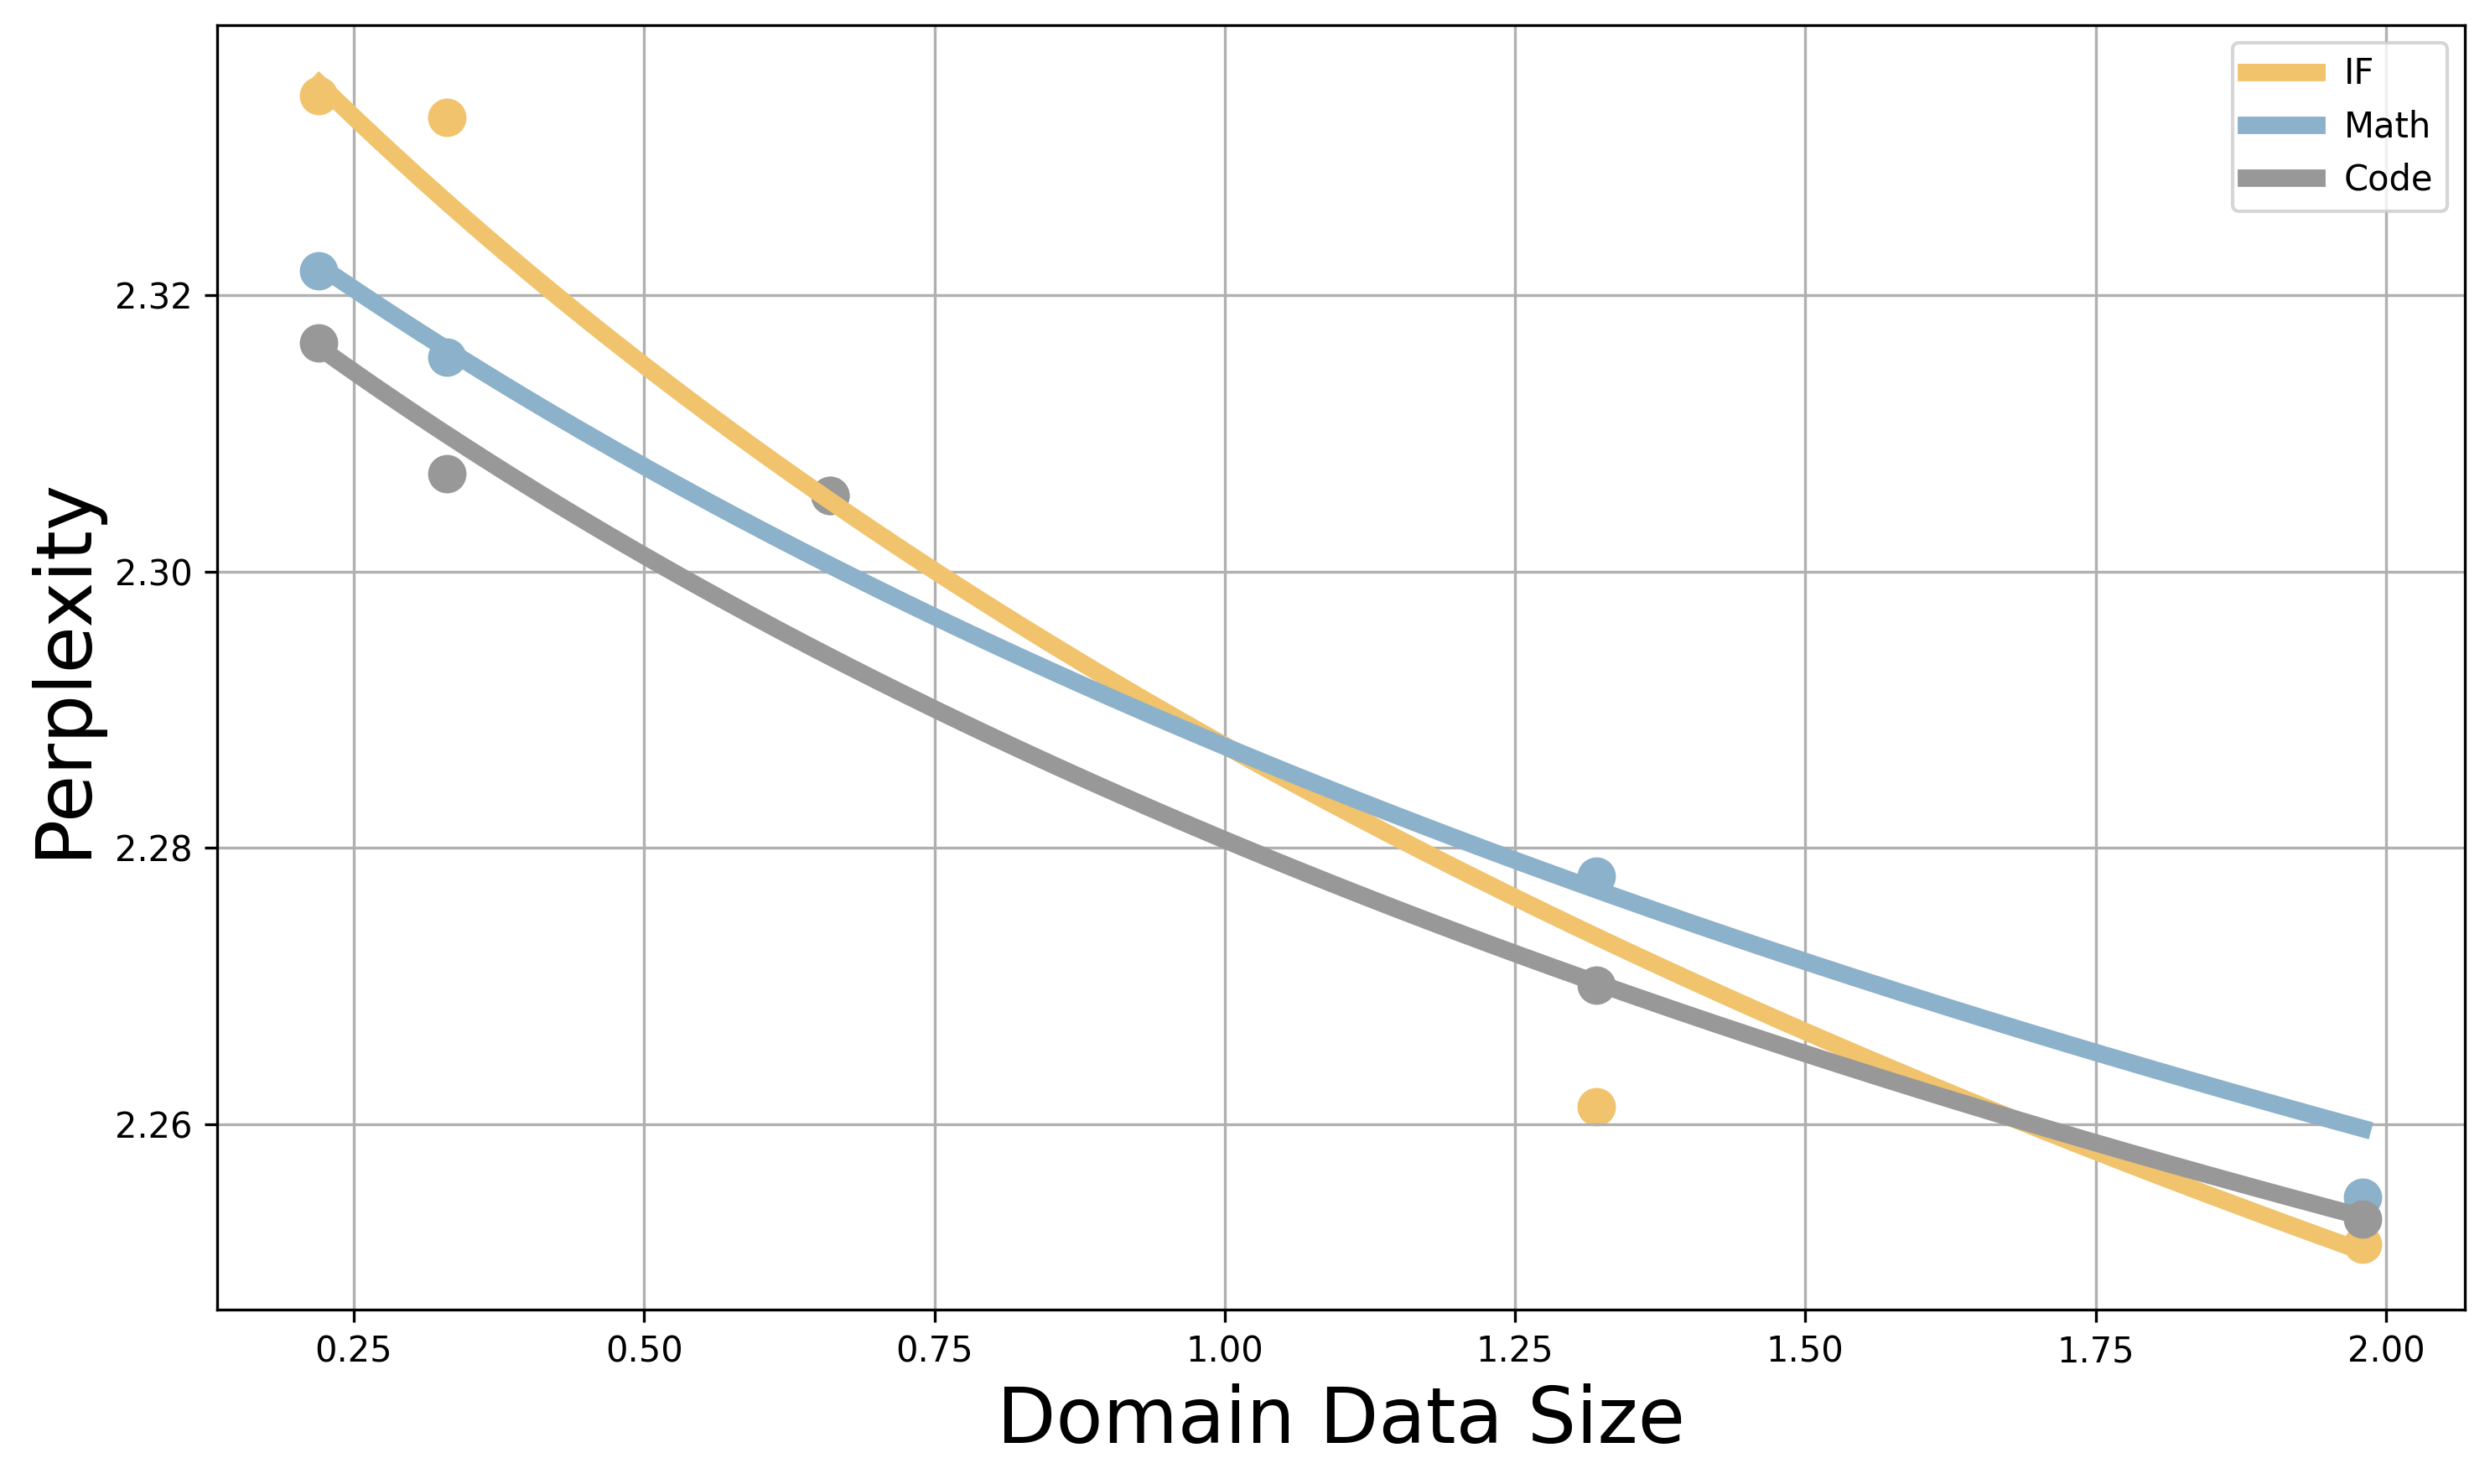


--- All Domains Completed ---
Domain 1 Parameters:
  Beta  = 0.107
  c     = 0.930
  gamma = 0.835
  alpha = 0.560
  e     = 1.423

Domain 2 Parameters:
  Beta  = 0.206
  c     = 0.470
  gamma = 1.144
  alpha = 0.507
  e     = 1.892

Domain 3 Parameters:
  Beta  = 0.279
  c     = 0.361
  gamma = 1.106
  alpha = 0.511
  e     = 1.994



In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, NonlinearConstraint, Bounds, BFGS

# ===============================================================
# 1. Data Setup
# ===============================================================
base_token = 0.66
N = 3 * base_token  # 'N' from your original context
x_vals = np.array([i * base_token for i in [1/3, 1/2, 1, 2, 3]])

# Each row in 'lyst' corresponds to a domain's L-values, i.e., 5 data points.
lyst = [
    [2.3344510239838225, 2.332892905356599, 2.305486517203082, 2.261286674352709, 2.251291523597417],  # 'instr'
    [2.3217512425787867, 2.315506112513719, 2.305486517203082, 2.2779459045407386, 2.2546816253283204],  # 'math'
    [2.316531607957455, 2.307071547605066, 2.305486517203082, 2.2700898714762863, 2.2531400735499223]     # 'code'
]
# Beta estimates from a prior approach:
beta_values = [0.1074, 0.2056, 0.2791]  # [IF, Math, Code]

# ===============================================================
# 2. Define the Model
#    c = exp(c_log), gamma = exp(gamma_log), e = exp(e_log)
# ===============================================================
def model(N_i, c_log, gamma_log, alpha, beta, e_log):
    """
    model(N_i) = exp(c_log) * (N_i + exp(gamma_log)*(2/3*N)^alpha)^(-beta) + exp(e_log)
    """
    c = np.exp(c_log)
    gamma_ = np.exp(gamma_log)
    e = np.exp(e_log)
    inner_term = (2.0/3.0) * N

    return c * (N_i + gamma_ * (inner_term ** alpha)) ** (-beta) + e

# ===============================================================
# 3. Huber Loss
# ===============================================================
def huber_loss(residuals, delta=0.001):
    """
    Huber loss for robust regression:
      - Quadratic for small residuals (|r| <= delta).
      - Linear for large residuals (|r| > delta).
    """
    abs_r = np.abs(residuals)
    mask_quadratic = abs_r <= delta

    # Quadratic region
    quad_part = 0.5 * residuals**2
    # Linear region
    linear_part = delta * (abs_r - 0.5 * delta)

    return np.where(mask_quadratic, quad_part, linear_part)

# ===============================================================
# 4. Objective for c_log, gamma_log, alpha, e_log with beta fixed
# ===============================================================
def objective_fixed_beta(params, x, y, beta_fixed):
    """
    params = [c_log, gamma_log, alpha, e_log]
       c_log     : real
       gamma_log : real
       alpha     : in [0,1]
       e_log     : real
    """
    c_log, gamma_log, alpha_, e_log = params

    # Compute predictions
    y_pred = model(x, c_log, gamma_log, alpha_, beta_fixed, e_log)
    # Residuals
    residuals = y - y_pred
    # Sum of Huber losses
    return np.sum(huber_loss(residuals, delta=0.001))

# ===============================================================
# 5. Constraint: exp(gamma_log)*(2/3*N)^alpha < (2/3*N)
# ===============================================================
def constraint_fun_fixed_beta(params, beta_fixed):
    """
    We want:  exp(gamma_log)*(inner_term^alpha) - inner_term <= 0
    where inner_term = (2/3*N).
    """
    # c_log = params[0]      # not needed here
    gamma_log = params[1]
    alpha_ = params[2]
    # e_log = params[3]      # not needed here

    inner_term = (2.0/3.0) * N
    return np.exp(gamma_log) * (inner_term ** alpha_) - inner_term

# ===============================================================
# 6. Parameter Bounds
#    c_log:    (-inf, inf)
#    gamma_log:(-inf, inf)
#    alpha:    [0, 1]
#    e_log:    (-inf, inf)
# ===============================================================
lb = [-np.inf, -np.inf, 0.0, -np.inf]
ub = [ np.inf,  np.inf, 1.0,  np.inf]
bounds_fixed_beta = Bounds(lb, ub)

# ===============================================================
# 7. Putting it all together
# ===============================================================
optimized_parameters = []

# To store data for plotting
plot_data = {
    'Domain': [],
    'Color': [],
    'x': [],
    'y': [],
    'y_fitted': []
}

# Define colors for each domain
domain_colors = ['#f0c36c', '#8CB1CA', '#989898']  # [IF, Math, Code]

for domain_index, (Lvals_raw, beta_est) in enumerate(zip(lyst, beta_values), start=1):
    Lvals = np.array(Lvals_raw)
    
    # Define objective and constraint for current domain
    def objective_to_minimize(p, x, y):
        return objective_fixed_beta(p, x, y, beta_est)
    
    def constraint_fun(p):
        return constraint_fun_fixed_beta(p, beta_est)
    
    # Nonlinear constraint for gamma
    nonlinear_constraint_fixed = NonlinearConstraint(
        fun=constraint_fun,
        lb=-np.inf,
        ub=0.0,     # exp(gamma_log)*(2/3*N)^alpha <= (2/3*N)
        jac='2-point',
        hess=BFGS()
    )
    
    # Initial guess
    #  c_log = 0.0       -> c=exp(0)=1.0
    #  gamma_log = 0.5   -> gamma=exp(0.5) ~1.65, just an example
    #  alpha=1.0         -> alpha=1.0
    #  e_log=2.0         -> e=exp(2)=7.389..., just an example
    initial_guess = [
        0.0,   # c_log
        0.5,   # gamma_log
        1.0,   # alpha
        2.0    # e_log
    ]
    
    # Optimize
    res = minimize(
        fun=objective_to_minimize,
        x0=initial_guess,
        args=(x_vals, Lvals),
        method='trust-constr',
        jac='2-point',
        hess=BFGS(),
        bounds=bounds_fixed_beta,
        constraints=[nonlinear_constraint_fixed],
        options={'maxiter': 3000, 'verbose': 0},
    )
    
    if res.success:
        c_log_opt, gamma_log_opt, alpha_opt, e_log_opt = res.x
        
        # Convert back to original scale for c, gamma, e
        c_opt = np.exp(c_log_opt)
        gamma_opt = np.exp(gamma_log_opt)
        e_opt = np.exp(e_log_opt)
        
        results_dict = {
            'beta': beta_est,
            'c': c_opt,
            'gamma': gamma_opt,
            'alpha': alpha_opt,
            'e': e_opt
        }
        optimized_parameters.append(results_dict)
        
        print(f"=== [Domain {domain_index}] Optimization Success ===")
        print(f"   c     = {c_opt:.6f}")
        print(f"   k = {gamma_opt:.6f}")
        print(f"   alpha = {alpha_opt:.6f}")
        print(f"   e     = {e_opt:.6f}")
        print(f"   Huber objective = {res.fun:.6f}")
        
        # Check constraint ratio
        inner_term = (2.0/3.0) * N
        ratio = gamma_opt * (inner_term ** alpha_opt) / inner_term
        print(f"   gamma*(2/3*N)^alpha / (2/3*N) = {ratio:.6f}")
        
        # Store data for plotting
        plot_data['Domain'].append(f"Domain {domain_index}")
        plot_data['Color'].append(domain_colors[domain_index - 1])
        plot_data['x'].append(x_vals)
        plot_data['y'].append(Lvals)
        
        # Compute fitted values
        x_fine = np.linspace(x_vals.min(), x_vals.max(), 200)
        y_fitted = model(x_fine, c_log_opt, gamma_log_opt, alpha_opt, beta_est, e_log_opt)
        plot_data['y_fitted'].append((x_fine, y_fitted))
        
    else:
        print(f"=== [Domain {domain_index}] Optimization Failed ===")
        print("Message:", res.message)

# ===============================================================
# 8. Plot All Domains in One High-Resolution Figure
# ===============================================================
# Define domain labels
domain_labels = ['IF', 'Math', 'Code']

# Create a high-resolution figure
plt.figure(figsize=(10, 6), dpi=300)

for idx in range(len(optimized_parameters)):
    domain_label = domain_labels[idx]
    color = domain_colors[idx]
    x = plot_data['x'][idx]
    y = plot_data['y'][idx]
    x_fine, y_fitted = plot_data['y_fitted'][idx]
    
    # Plot data points
    plt.scatter(x, y, color=color, marker='o', s = 100)
    
    # Plot fitted curve
    plt.plot(x_fine, y_fitted, color=color, linestyle='-', linewidth=5, label=f'{domain_label}')

# Customize the plot
plt.xlabel('Domain Data Size', fontsize=22)
plt.ylabel('Perplexity', fontsize=22)
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save the figure with high resolution
plt.savefig('fitted_models_high_resolution.png', dpi=300)

# Display the plot
plt.show()

# ===============================================================
# 9. Print Summaries
# ===============================================================
print("\n--- All Domains Completed ---")
for idx, param_dict in enumerate(optimized_parameters, start=1):
    print(f"Domain {idx} Parameters:")
    print(f"  Beta  = {param_dict['beta']:.3f}")
    print(f"  c     = {param_dict['c']:.3f}")
    print(f"  gamma = {param_dict['gamma']:.3f}")
    print(f"  alpha = {param_dict['alpha']:.3f}")
    print(f"  e     = {param_dict['e']:.3f}\n")


In [4]:
optimized_parameters

[{'beta': 0.1074,
  'c': 0.9303720966305796,
  'gamma': 0.8353839985461634,
  'alpha': 0.5601292648858495,
  'e': 1.4226529933436454},
 {'beta': 0.2056,
  'c': 0.47001708560647254,
  'gamma': 1.1442480438863765,
  'alpha': 0.5074276704841271,
  'e': 1.8919117116032493},
 {'beta': 0.2791,
  'c': 0.36073465526930765,
  'gamma': 1.106071287791263,
  'alpha': 0.5113088104398635,
  'e': 1.9937865053832902}]

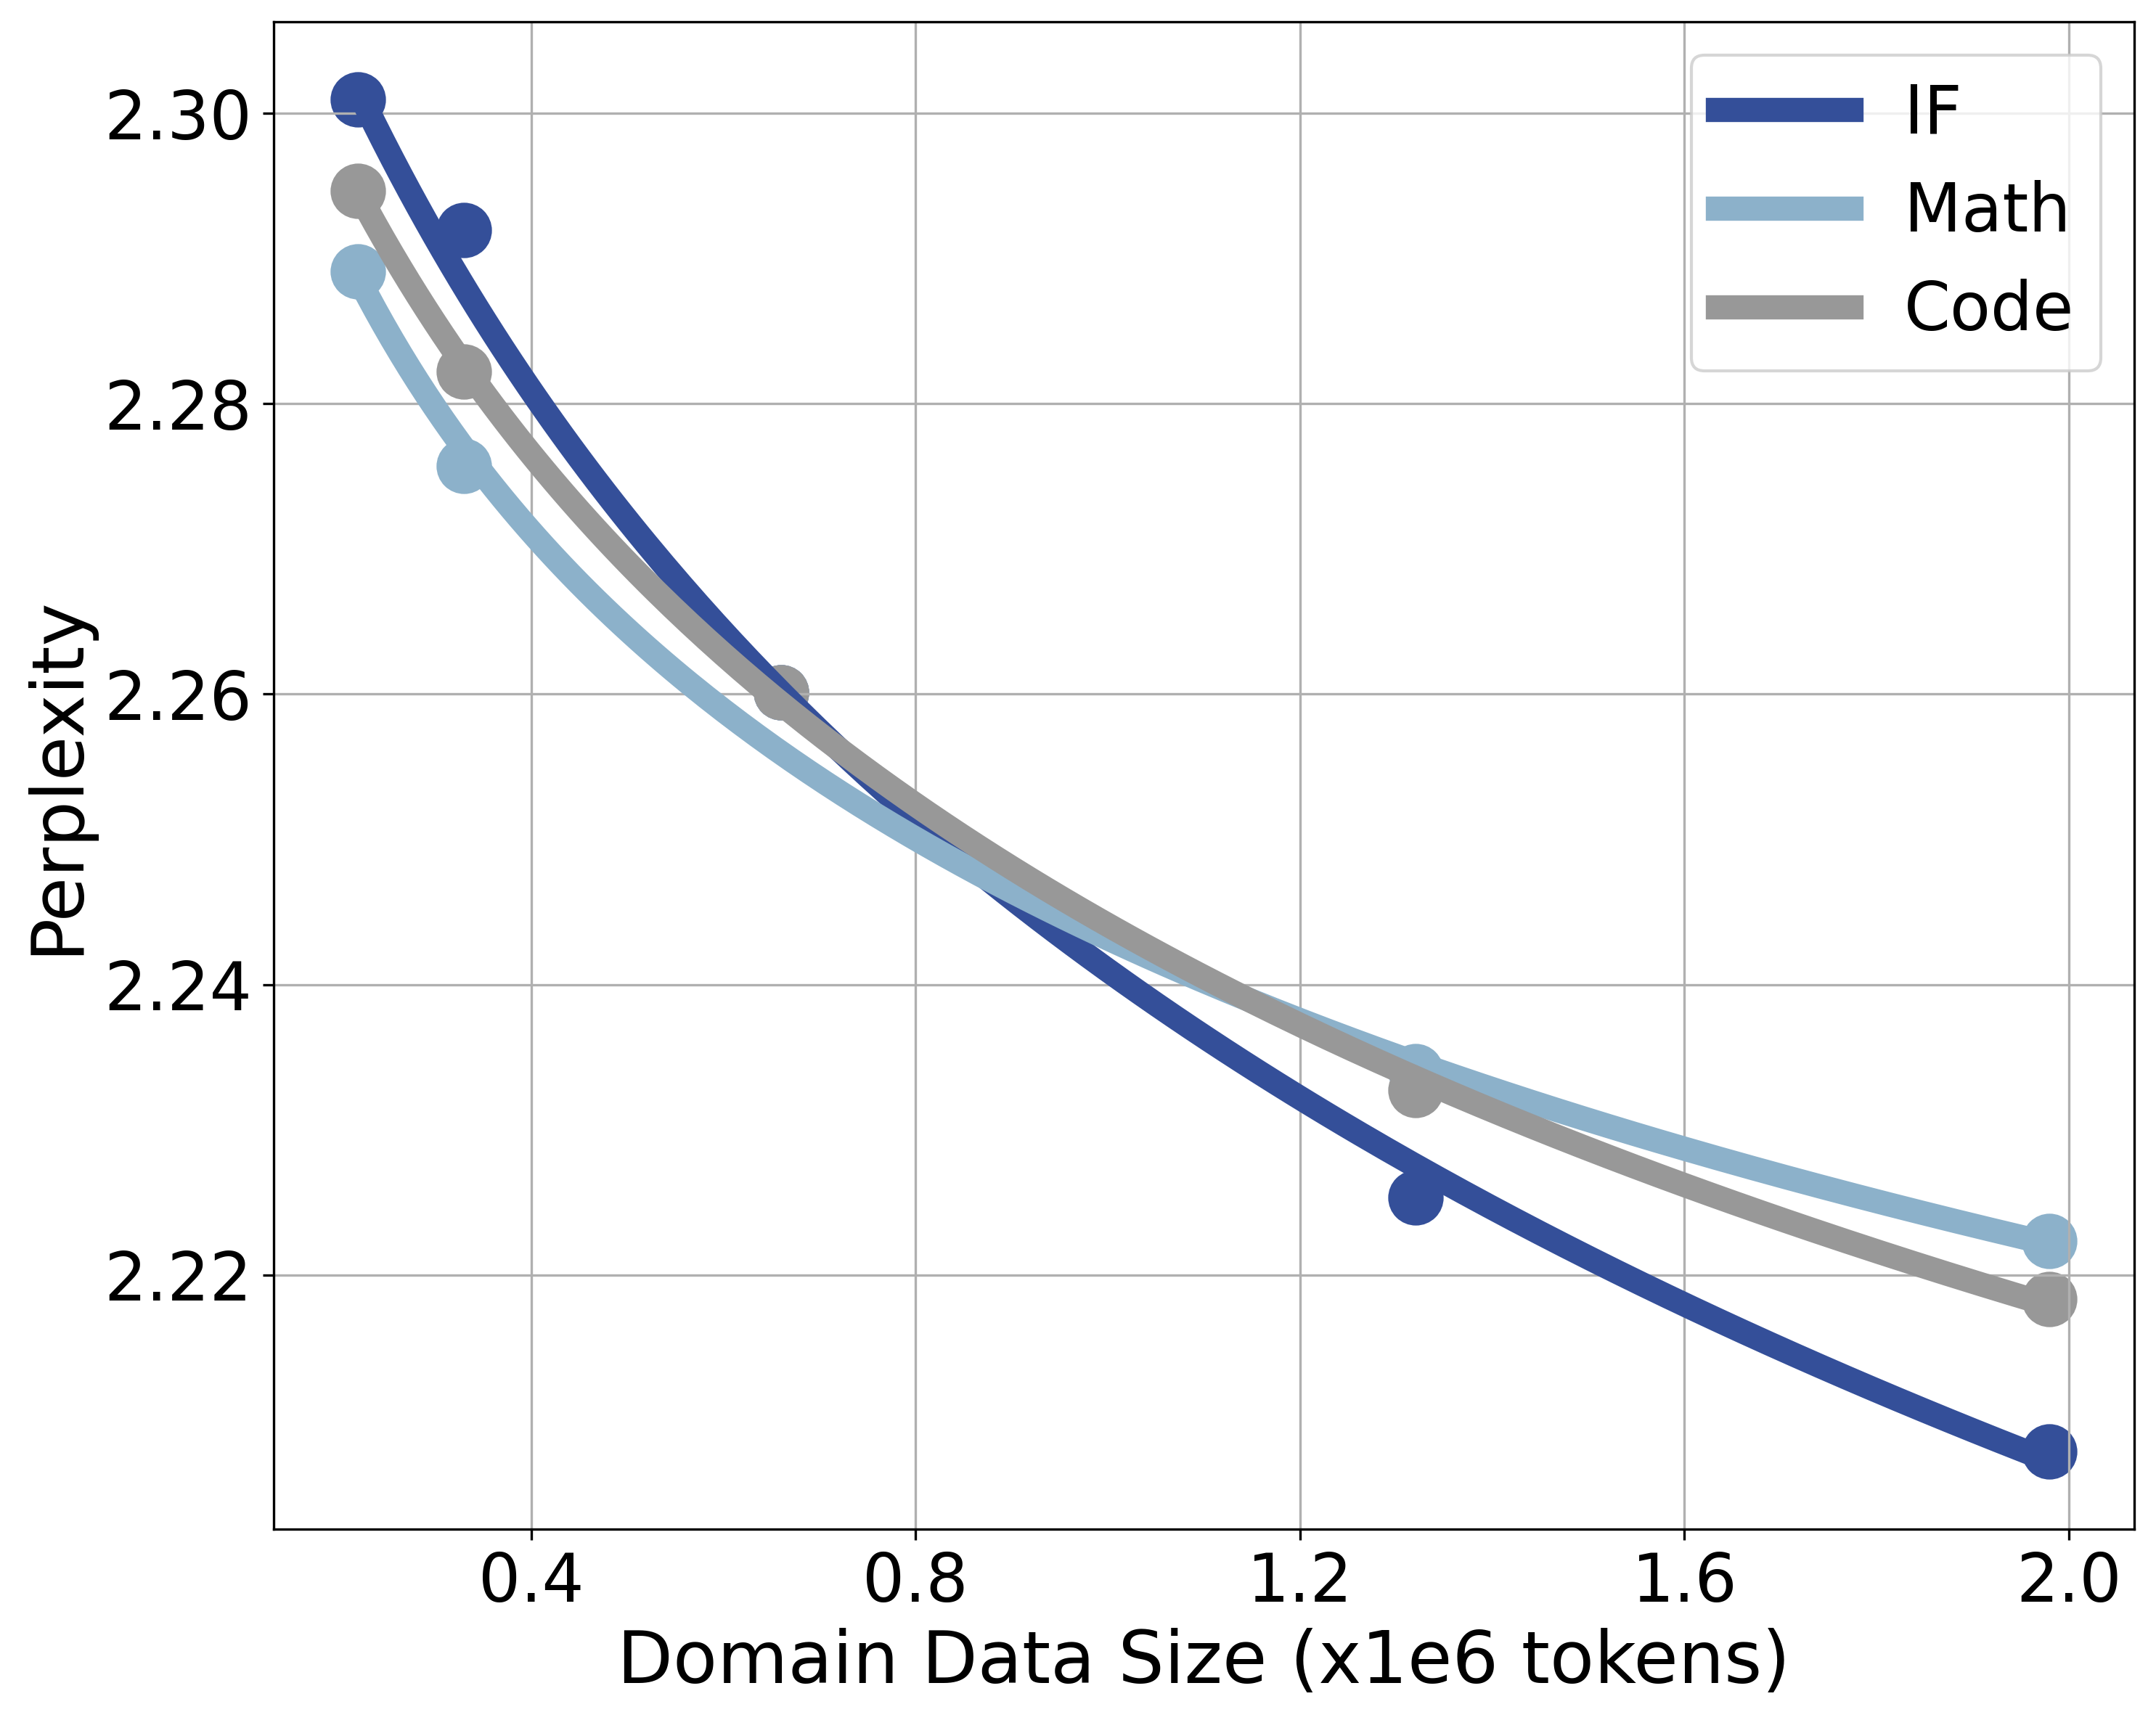

In [35]:
from matplotlib.ticker import MaxNLocator
fig, ax = plt.subplots(figsize=(10, 8), dpi=300)

domain_colors = ["#344F99", '#8CB1CA', '#989898']

for idx in range(len(optimized_parameters)):
    domain_label = domain_labels[idx]
    color = domain_colors[idx]
    x = plot_data['x'][idx]
    y = plot_data['y'][idx]
    x_fine, y_fitted = plot_data['y_fitted'][idx]
    
    # Plot data points
    plt.scatter(x, y, color=color, marker='o', s=300)
    
    # Plot fitted curve
    plt.plot(x_fine, y_fitted, color=color, linestyle='-', linewidth=8, label=f'{domain_label}')
    
# ax.set_xlabel('Domain Data Size (x10³ tokens)', fontsize=24)
# ax.set_ylabel('Perplexity', fontsize=24)

# Customize tick parameters
ax.tick_params(axis='both', which='major', labelsize=22)
ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
# Customize the plot
plt.xlabel('Domain Data Size (x1e6 tokens)', fontsize=24)
plt.ylabel('Perplexity', fontsize=24)
plt.legend(fontsize = 22)
plt.grid(True)
plt.tight_layout()

# Save the figure with high resolution
plt.savefig('fitted_models.pdf', dpi=300)

# Display the plot
plt.show()